# Tutorial 3: Temporal Correlations and How to Handle Them

In Tutorial 1, we estimated MI on IID data: each sample was drawn independently,
with no relationship to its neighbours. We used `Split(mode='random')` and got
a reliable result.

Real neural recordings are never IID. A spike pattern at time $t$ is correlated
with the pattern at time $t+1$, $t+2$, and beyond. An LFP oscillation has a
timescale of tens to hundreds of milliseconds. Kinematics are smooth. In all
of these cases, **adjacent samples in your dataset are not independent** — and
this has profound consequences for how you must split your data.

This tutorial demonstrates two things:

1. **The split-mode problem.** Using `Split(mode='random')` on autocorrelated
   data silently inflates MI estimates. We will show this concretely with numbers.

2. **The window-size problem.** Even with the correct split mode, choosing a
   window that is too short gives near-zero MI, because information in neural
   signals is not instantaneous — it is spread over a timescale. Choosing the
   right window size is the subject of Tutorial 4; here we build the intuition.

## 1. Autocorrelated Data

We begin by generating synthetic data with rich temporal autocorrelation —
a signal whose value at any moment depends on its recent history, just like
a real LFP or spike rate trace.

We use `nmi.generators.generate_windowed_dependency_data` function,
which produces a multichannel signal with a tunable autocorrelation timescale.
Alongside it we get a paired variable $Y$ that shares information with $X$
through a causal history integration window — so the MI between them is real,
but only visible when the analysis window is long enough to capture that history.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import neural_mi as nmi

sns.set_context("talk")
np.random.seed(42)

In [2]:
n_timepoints = 5000
n_channels = 4
timescale = 50   # dominant autocorrelation timescale in samples

x_raw, y_raw = nmi.generators.generate_windowed_dependency_data(
    n_timepoints=n_timepoints,
    n_channels=n_channels,
    timescale=timescale,
    history_window=timescale,
)

# x_raw shape: (n_timepoints, n_channels) — timepoints first, ready for processor
print(f"X shape: {x_raw.shape}  (n_timepoints, n_channels)")
print(f"Y shape: {y_raw.shape}  (n_timepoints, n_channels)")

X shape: torch.Size([5000, 4])  (n_timepoints, n_channels)
Y shape: torch.Size([5000, 4])  (n_timepoints, n_channels)


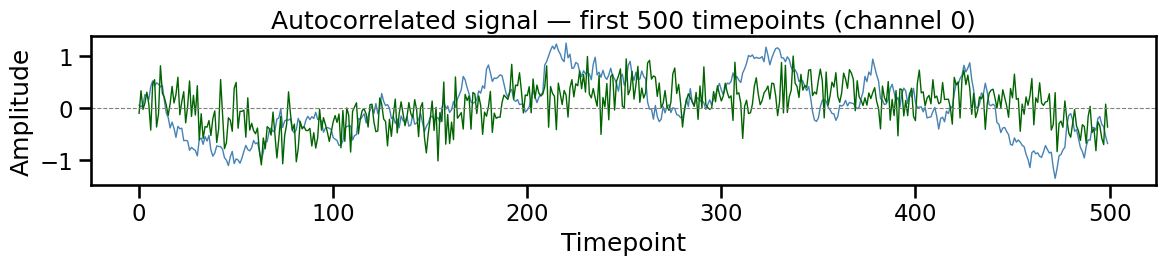

In [3]:
# Plot the first 500 timepoints of channel 0 to see the autocorrelated structure.
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(x_raw[:500, 0], color='steelblue', linewidth=1)
ax.plot(y_raw[:500, 0], color='darkgreen', linewidth=1)
ax.axhline(0, linestyle='--', color='grey', linewidth=0.8)
ax.set_xlabel("Timepoint")
ax.set_ylabel("Amplitude")
ax.set_title("Autocorrelated signal — first 500 timepoints (channel 0)")
plt.tight_layout()
plt.show()

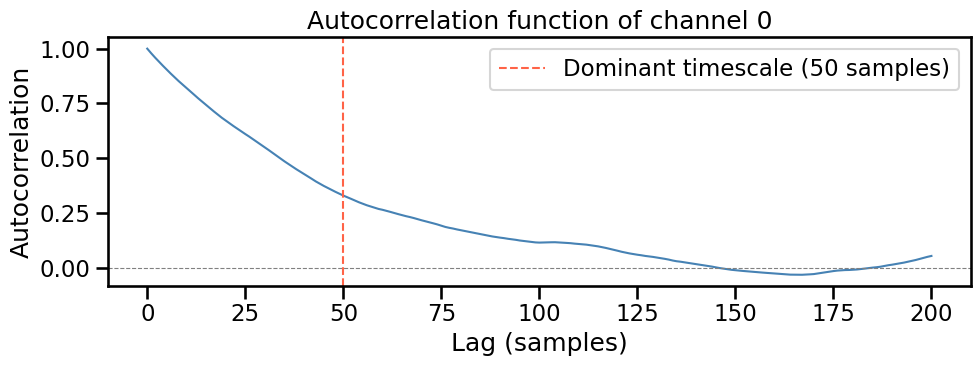

In [4]:
# Compute and plot the autocorrelation function of channel 0 for lags 0 to 200.
max_lag = 200
ch0 = x_raw[:, 0]
ch0_norm = ch0 - ch0.mean()
acf = np.array([
    np.corrcoef(ch0_norm[:-k], ch0_norm[k:])[0, 1] if k > 0
    else 1.0
    for k in range(max_lag + 1)
])


fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.arange(max_lag + 1), acf, color='steelblue', linewidth=1.5)
ax.axhline(0, linestyle='--', color='grey', linewidth=0.8)
ax.axvline(timescale, linestyle='--', color='tomato', linewidth=1.5,
           label=f"Dominant timescale ({timescale} samples)")
ax.set_xlabel("Lag (samples)")
ax.set_ylabel("Autocorrelation")
ax.set_title("Autocorrelation function of channel 0")
ax.legend()
plt.tight_layout()
plt.show()

The autocorrelation is clearly non-zero for many lags beyond zero — this is
the temporal structure that makes random splits dangerous.

Notice that the ACF is not a simple single-exponential decay: it has a shoulder
at longer lags contributed by the slow AR component. This non-trivial shape is
realistic for neural data, where multiple timescales coexist (e.g., a gamma
oscillation riding on top of a slower theta rhythm).

The key principle: **if adjacent samples are correlated, a randomly chosen test
sample is almost certainly correlated with its neighbouring training samples,
and the test MI is not a genuine measure of generalisation.** The network can
effectively interpolate between its temporally adjacent training neighbours,
producing an inflated test MI that does not reflect the true dependence between
$X$ and $Y$.

## 2. The Split-Mode Problem

How does NeuralMI estimate MI? The library trains a neural network critic on
a training set and evaluates it on a held-out test set at the end of every
epoch. It tracks the **test MI** across epochs and reports the value at the
epoch where test MI is maximised — the most generalising model. This "max test"
principle is what makes the estimator reliable: by selecting the model that
best generalises to unseen data, we avoid overfitting.

This principle only works if the test set is genuinely unseen. With IID data,
any randomly chosen fraction of samples satisfies this — each test sample is
independent of all training samples by construction.

With autocorrelated time-series data, a random split fails badly. A test sample
at time $t$ is flanked by training samples at $t-1$ and $t+1$, which are highly
correlated with it. The network does not need to learn a general representation
— it can effectively interpolate between its training neighbours. The resulting
test MI is inflated: it reflects memorisation of local autocorrelation, not
genuine information-theoretic dependence between $X$ and $Y$.

Let's demonstrate this with numbers.

**A note on `step_size` before we run anything.** Tutorial 2 established
non-overlapping windows as the library's default windowing scheme. Below
(and in the rest of this tutorial) we pass `step_size=10`, which produces
*overlapping* windows instead. This is not a contradiction: overlap is a
legitimate way to increase the effective number of (correlated) samples,
which matters on a dataset this size, where strictly non-overlapping windows
would leave very few of them. The safety property that makes this fine is
that overlap only ever happens *within* the pre-specified train and test
regions — a training window and a test window are never allowed to overlap
each other, so there is no leakage or train/test ambiguity, only a change in
how many (correlated) windows each region is cut into.

In [5]:
training = nmi.Training(n_epochs=200, patience=50, learning_rate=1e-4)

print("Running with Split(mode='random') (INCORRECT for time-series data)...")
results_random = nmi.run(
    x_raw, y_raw,
    mode='estimate',
    processing=nmi.Processing(x='continuous', x_params={'window_size': timescale, 'step_size': 10},  # some overlap to capture more temporal structure, yet wrong mode
                              y='continuous', y_params={'window_size': timescale, 'step_size': 10}),
    split=nmi.Split(mode='random'),   # WRONG for autocorrelated data — for demonstration only
    training=training,
)

print(f"MI with random split:  {results_random.mi_estimate:.3f} bits")

Running with Split(mode='random') (INCORRECT for time-series data)...


/Users/eabdelaleem3/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Postdoc Projects/neuralmI_paper/NeuralMI/.claude/worktrees/epic-shannon-555143/neural_mi/run.py:275: UserWarning: Small dataset detected (499 windows). Regularisation may help: consider adding dropout=0.1 and norm_layer='layer' to your Model config.
  return _run_flat(x_data, y_data, **flat, **analysis_kwargs)


Run 11fc6aa1-bd0a-4bb1-9b54-7bfdd0ec2af2_c0:   0%|          | 0/200 [00:00<?, ?it/s]

MI with random split:  5.201 bits


In [6]:
print("Running with Split(mode='blocked') (CORRECT for time-series data)...")
results_blocked = nmi.run(
    x_raw, y_raw,
    mode='estimate',
    processing=nmi.Processing(x='continuous', x_params={'window_size': timescale, 'step_size': 10},  # some overlap to capture more temporal structure, yet correct mode
                              y='continuous', y_params={'window_size': timescale, 'step_size': 10}),
    split=nmi.Split(mode='blocked'),  # CORRECT for time-series data: contiguous test blocks
    training=training,
)

print(f"MI with blocked split: {results_blocked.mi_estimate:.3f} bits")
print(f"\nInflation from random split: "
      f"{results_random.mi_estimate - results_blocked.mi_estimate:+.3f} bits")

Running with Split(mode='blocked') (CORRECT for time-series data)...


/Users/eabdelaleem3/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Postdoc Projects/neuralmI_paper/NeuralMI/.claude/worktrees/epic-shannon-555143/neural_mi/run.py:275: UserWarning: Small dataset detected (499 windows). Regularisation may help: consider adding dropout=0.1 and norm_layer='layer' to your Model config.
  return _run_flat(x_data, y_data, **flat, **analysis_kwargs)


Run 2ca5dad7-4be2-4d1b-b2ed-ae622cbc47b9_c0:   0%|          | 0/200 [00:00<?, ?it/s]

MI with blocked split: 4.676 bits

Inflation from random split: +0.525 bits


The random split produces a higher (inflated) MI estimate. The **exact** numbers
will vary from run to run — this is a noisy, stochastic estimation process, so
if you re-run this notebook the two values will shift — but the **trend is
robust**: on autocorrelated data the random split consistently comes out higher
than the blocked split. The size of the gap depends on the autocorrelation
timescale relative to the window size — the stronger the autocorrelation, the
larger the inflation tends to be.

This is not a numerical rounding artefact: it is the estimator being rewarded for
interpolating between temporally adjacent train and test samples. On strongly
autocorrelated recordings the inflation can be large enough to make a null result
look significant, and there is no way to correct for it after the fact — the split
mode must be set correctly *before* running.

The blocked estimate is the trustworthy one: it measures whether the network can
generalise to genuinely unseen segments of the recording. The random estimate
measures something else — local predictability from temporal autocorrelation.

## 3. What Blocked Splitting Actually Does

The `Split(mode='blocked')` option (the library default) carves out
contiguous chunks of the recording as test data, rather than scattering
random points. The key parameters are:

- `n_test_blocks` (default 5): how many contiguous test chunks to use.
  More blocks give better coverage of the recording's variability.
- `gap_fraction` (default 0.5): a buffer zone, expressed as a fraction
  of the block width, that is excluded from training on either side of each
  test block. This prevents training samples that are temporally adjacent
  to test samples from leaking correlated information into training.
- `train_fraction` (default 0.9): the fraction of data used for training.
  The remainder is test.

Let's visualise what this looks like on our 10,000-sample recording.

In [ ]:
# Simulate the blocked split geometry for illustration.
# The internal splitting logic happens automatically inside nmi.run(), but here we manually create the category labels for each window to visualise the split geometry.
n_windows = n_timepoints // timescale  # windows after processing: 5000 // 50 = 100
test_fraction = 0.1
n_test_blocks = 5
total_test_windows = int(test_fraction * n_windows)
windows_per_block = total_test_windows // n_test_blocks
gap = int(0.5 * windows_per_block)  # gap on each side of each test block

# Place 5 blocks evenly across the recording
block_spacing = n_windows // (n_test_blocks + 1)
block_starts = [block_spacing * (i + 1) - windows_per_block // 2
                for i in range(n_test_blocks)]

# Assign each window to a category
categories = np.zeros(n_windows, dtype=int)  # 0=training (default)
for bs in block_starts:
    # Gap on each side
    gap_start = max(0, bs - gap)
    gap_end = min(n_windows, bs + windows_per_block + gap)
    categories[gap_start:gap_end] = 2  # orange = gap
    # Test block overrides
    tb_start = max(0, bs)
    tb_end = min(n_windows, bs + windows_per_block)
    categories[tb_start:tb_end] = 1   # red = test

fig, ax = plt.subplots(figsize=(14, 2))
colors = {0: '#4878cf', 1: '#e84646', 2: '#f0a500'}
labels = {0: 'Training', 1: 'Test block', 2: 'Gap (excluded)'}
handles = {}
for w in range(n_windows):
    cat = categories[w]
    bar = ax.barh(0, 1, left=w, color=colors[cat], height=0.8)
    if cat not in handles:
        handles[cat] = bar

ax.legend([handles[k] for k in sorted(handles)],
          [labels[k] for k in sorted(handles)], loc='upper right')
ax.set_title("Blocked split geometry (n_test_blocks=5, gap_fraction=0.5)")
ax.set_xlabel("Window index")
ax.set_yticks([])
ax.set_xlim(0, n_windows)
plt.show()

n_train = int((categories == 0).sum())
n_test = int((categories == 1).sum())
n_gap = int((categories == 2).sum())
print(f"Total windows:    {n_windows}")
print(f"Training windows: {n_train}")
print(f"Test windows:     {n_test}  (spread across {n_test_blocks} blocks)")
print(f"Gap windows:      {n_gap}  (excluded from both sets)")

Each red block is a contiguous chunk of the recording that the network never
sees during training. The orange gap on either side of each block ensures that
even the training samples immediately adjacent to the test block are excluded
— they would be correlated with the test samples and would otherwise leak
information.

The five blocks are spread across the recording rather than clustered in one
place. This is important because neural recordings are often non-stationary:
the animal's behaviour, arousal state, or experimental condition changes over
time. By sampling test blocks from different parts of the recording, we ensure
that the test set captures the full variability of the data.

**Rule of thumb:** Always use `Split(mode='blocked')` (the default) for any
data that came from a continuous recording. Use `Split(mode='random')` only
when your samples are genuinely independent — for example, if each row of
your data matrix is a separate trial with a random inter-trial interval, or
if you explicitly generated IID data.

## 4. The Window-Size Problem

Even with the correct split mode, there is a second decision that interacts
with the autocorrelation structure of the data: the **window size**.

MI in neural signals is not instantaneous. A neuron's firing rate encodes
a stimulus over tens to hundreds of milliseconds. An LFP oscillation carries
phase information over a full cycle. If your analysis window is shorter than
the timescale over which information is encoded, you are asking the estimator
to find information that isn't visible at that resolution — and you will get
near-zero MI regardless of how much information is actually there.

Conversely, a window that is too long reduces your sample count (fewer
non-overlapping windows fit in the recording), which increases the finite-sample
bias we discussed in Tutorial 1.

Let's demonstrate the effect of window size on our data, using the correct
`Split(mode='blocked')` throughout. We'll see in the next tutorial how to perform
such sweeps using `mode='sweep'`.

In [8]:
window_sizes = [10, 30, 50, 70, 100, 150, 200]
mi_per_window = []

for ws in window_sizes:
    r = nmi.run(
        x_raw, y_raw,
        mode='estimate',
        processing=nmi.Processing(x='continuous', x_params={'window_size': ws, 'step_size': 10},  # some overlap to capture more temporal structure
                                  y='continuous', y_params={'window_size': ws, 'step_size': 10}),
        split=nmi.Split(mode='blocked'),  # CORRECT for time-series data
        training=training,
    )
    mi_per_window.append(r.mi_estimate)
    print(f"window_size={ws:4d}  →  MI = {r.mi_estimate:.3f} bits")

Run 3644f431-9fca-4d8c-bcee-1b3b9658b701_c0:   0%|          | 0/200 [00:00<?, ?it/s]

window_size=  10  →  MI = 2.157 bits


Run d3435629-f1f3-4481-8164-0ee36446da00_c0:   0%|          | 0/200 [00:00<?, ?it/s]

window_size=  30  →  MI = 4.372 bits


Run cca58d06-bdb3-488d-938f-db600a011227_c0:   0%|          | 0/200 [00:00<?, ?it/s]

...

Run 44e6f9f3-fb9b-4cd5-a233-da181845e37e_c0:   0%|          | 0/200 [00:00<?, ?it/s]

window_size= 150  →  MI = 4.808 bits


/Users/eabdelaleem3/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Postdoc Projects/neuralmI_paper/NeuralMI/.claude/worktrees/epic-shannon-555143/neural_mi/run.py:275: UserWarning: Small dataset detected (496 windows). Regularisation may help: consider adding dropout=0.1 and norm_layer='layer' to your Model config.
  return _run_flat(x_data, y_data, **flat, **analysis_kwargs)


Run f0ca5ad2-cb4a-441f-a2c5-a2b3cdc5716e_c0:   0%|          | 0/200 [00:00<?, ?it/s]

window_size= 200  →  MI = 5.433 bits


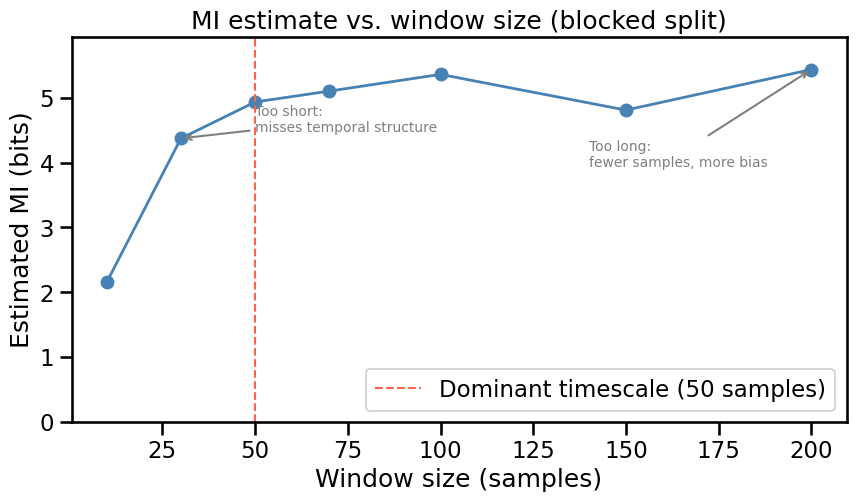

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(window_sizes, mi_per_window, 'o-', color='steelblue', linewidth=2)
ax.axvline(timescale, linestyle='--', color='tomato', linewidth=1.5,
           label=f"Dominant timescale ({timescale} samples)")
ax.annotate("Too short:\nmisses temporal structure",
            xy=(window_sizes[1], mi_per_window[1]),
            xytext=(window_sizes[1] + 20, mi_per_window[1] + 0.1),
            fontsize=10, color='grey',
            arrowprops=dict(arrowstyle='->', color='grey'))
ax.annotate("Too long:\nfewer samples, more bias",
            xy=(window_sizes[-1], mi_per_window[-1]),
            xytext=(window_sizes[-2] - 10, mi_per_window[-1] - 1.5),
            fontsize=10, color='grey',
            arrowprops=dict(arrowstyle='->', color='grey'))
ax.set_xlabel("Window size (samples)")
ax.set_ylabel("Estimated MI (bits)")
ax.set_title("MI estimate vs. window size (blocked split)")
ax.legend()
plt.ylim(0, np.amax(mi_per_window) + 0.5)
plt.show()

The curve rises steeply as window size increases from very short values — short
windows simply cannot capture the temporal structure the information lives in.
Once the window is long enough (roughly the dominant autocorrelation timescale),
the estimate stops rising sharply and instead **hovers and fluctuates** around a
level rather than climbing cleanly or settling on a single value. This is a
noisy, stochastic estimator: re-running the sweep moves the individual points
around, and longer windows edge higher in some runs and dip in others — there is
no reliable monotonic trend past the useful range.

Part of that noise is a real trade-off: longer windows mean **fewer
non-overlapping samples**, so each estimate is built on less data and becomes
less reliable. The practical goal is therefore not a single 'best' window but a
**region** where the estimate is both high and reasonably stable — and finding
that region reliably calls for repeated runs and a systematic search, which is
exactly what `mode='sweep'` is designed for and the subject of **Tutorial 4**.

Notice that throughout this sweep we used `Split(mode='blocked')`. If we had used
`Split(mode='random')`, every point on this curve would be inflated by temporal
autocorrelation — potentially leading us to pick a window size that looks optimal
but is not.

**A note on units.** Every number on the curve above is a *per-window* MI —
"4.9 bits" at `window_size=50` means 4.9 bits **per 50-sample window**, not
4.9 bits per sample or per second. Because the x-axis changes what a window
covers, the curve is not telling you that longer windows carry proportionally
more information (MI is not linear in window size, and it visibly plateaus
here rather than climbing indefinitely) — it is telling you how much
information a *window of that specific size* carries. For a real recording
with a known sample rate, the way to make windows of different sizes
comparable is to additionally report a **rate**: divide the per-window MI by
the window's duration in seconds to get bits/s, and report both numbers side
by side (per-window for "how much does one window tell you," bits/s for
comparing across window sizes or across datasets). We report per-window here
because this tutorial's `window_size` is in abstract samples with no declared
sample rate — the principle applies whenever you attach a real sample rate to
your own data. This distinction does not apply to static (non-windowed) data,
where there is no window to normalize by and a bare MI value is unambiguous.

## 5. The Decision Table

To summarise, here is a practical decision guide for every call to `nmi.run()`.

| Your data | Correct `Split(mode=...)` | Reasoning |
|-----------|---------------------|-----------|
| IID samples (trials, stimuli drawn randomly) | `'random'` | Samples are independent by construction |
| Continuous recording (LFP, EEG, Ca²⁺, kinematics) | `'blocked'` (default) | Adjacent samples are correlated |
| Binned spike matrix from continuous session | `'blocked'` (default) | Same as continuous recording |
| Raw spike times from continuous session | `'blocked'` (default) | Same as continuous recording |
| Pre-processed windows from a continuous recording | `'blocked'` (default) | Windows are still temporally ordered |

| Signal type | Typical timescale | Starting window size |
|------------|------------------|---------------------|
| LFP oscillations (gamma ~40 Hz) | ~25 ms | 50–100 ms |
| Spike rate (single trial) | 50–200 ms | 100–300 ms |
| Kinematics (arm reaching) | 200–500 ms | 300–600 ms |
| Calcium imaging (slow indicator) | 500–2000 ms | 1–3 s |

**Note:** These are starting points. Always verify with a `mode='sweep'` over
`window_size` (Tutorial 4) before committing to a final value.

## 6. Key Takeaways

- **`Split(mode='blocked')` is the correct default for all neural recordings.**
  The library default is `'blocked'` for this reason. Only override it to
  `'random'` when your samples are genuinely IID.

- **Random splits on autocorrelated data inflate MI estimates.** The inflation
  is not a small rounding error — it can be large enough to make a null result
  appear significant. There is no correction for this after the fact; the split
  mode must be set correctly before running.

- **The MI estimator reports the test MI at the epoch that maximises test performance.**
  This "max test" principle is what makes the estimator reliable — but only when
  the test set is a genuine held-out set, not correlated with training.

- **Blocked splits use `n_test_blocks` contiguous chunks spread across the recording,
  with a gap buffer (`gap_fraction`) on each side.** These parameters can
  be tuned, but the defaults (5 blocks, 0.5 gap fraction) are appropriate for
  most recordings.

- **Window size must match the timescale of information encoding.** A window
  that is too short gives near-zero MI even when the true MI is substantial.
  Use `mode='sweep'` (Tutorial 4) to find the right window size for your data.

## Common Mistakes

1. **Using `Split(mode='random')` because it was the default in Tutorial 1.**
   Tutorial 1 used IID data, which is the one case where random splits are valid.
   For any recorded time series, `'blocked'` is the correct choice and is the
   library default. If you find yourself adding `Split(mode='random')` explicitly,
   pause and ask whether your samples are truly independent.

2. **Choosing a window size based on computational convenience.**
   A window size of 1 (a single sample) is the fastest to compute but gives
   near-zero MI for any signal with temporal structure. Always think about the
   timescale of the phenomenon you are trying to measure, and use a sweep to
   confirm that you are in the plateau region.

3. **Interpreting inflated MI from a random split as a positive result.**
   If you switch from `Split(mode='random')` to `Split(mode='blocked')` and your
   MI estimate drops substantially, the blocked estimate is the correct one.
   The random estimate was measuring autocorrelation within the data, not
   genuine information shared between $X$ and $Y$.

## What's Next

We now know that we need blocked splits and the right window size — but we
have not yet shown how to *find* the right window size systematically, or
how to choose the model architecture. **Tutorial 4** introduces `mode='sweep'`:
an automated search over any combination of parameters (window size, network
depth, embedding dimension) that lets you explore the parameter space
efficiently before committing to a final analysis.